# Diabetes Prediction Using Machine Learning
## Pima Indians Diabetes Dataset

This notebook builds and evaluates two classifiers — **Logistic Regression** and **Linear Discriminant Analysis (LDA)** — to predict the onset of diabetes based on diagnostic measurements. The dataset originates from the National Institute of Diabetes and Digestive and Kidney Diseases.

---
## Section 1 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    confusion_matrix, f1_score, accuracy_score,
    precision_score, recall_score,
    roc_curve, auc, roc_auc_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
## Section 2 — Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('Columns:', df.columns.tolist())
print()
df.info()

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
print('Missing values per column:')
print(df.isnull().sum())
rows, cols = df.shape
print(f'\nDataset shape: {rows} rows X {cols} columns')
print(f'Class balance (Outcome):\n{df["Outcome"].value_counts()}')

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset shape: 768 rows X 9 columns
Class balance (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64


### 2.1 — Correlation Heatmap

A correlation heatmap shows pairwise linear relationships between all numeric features. Strong positive correlation with `Outcome` indicates a feature that tends to be higher in diabetic patients.

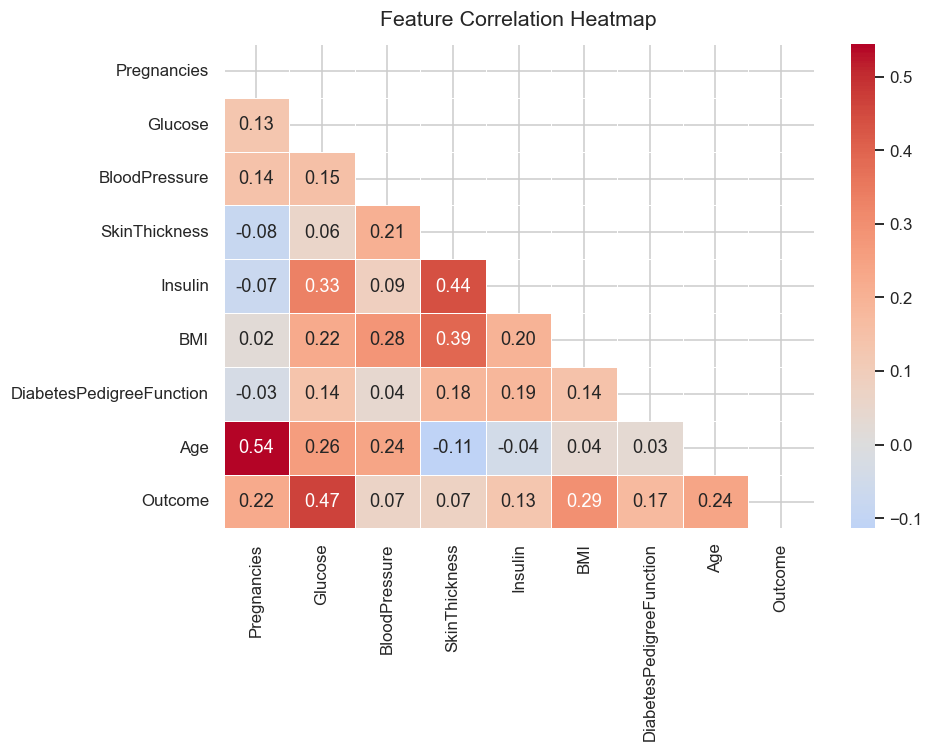


Correlation with Outcome (sorted):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print('\nCorrelation with Outcome (sorted):')
print(corr['Outcome'].sort_values(ascending=False))

### 2.2 — Per-Feature Histograms

Histograms reveal the distribution of each feature, separated by class (diabetic vs. non-diabetic). This makes it easy to spot features that differ between the two groups.

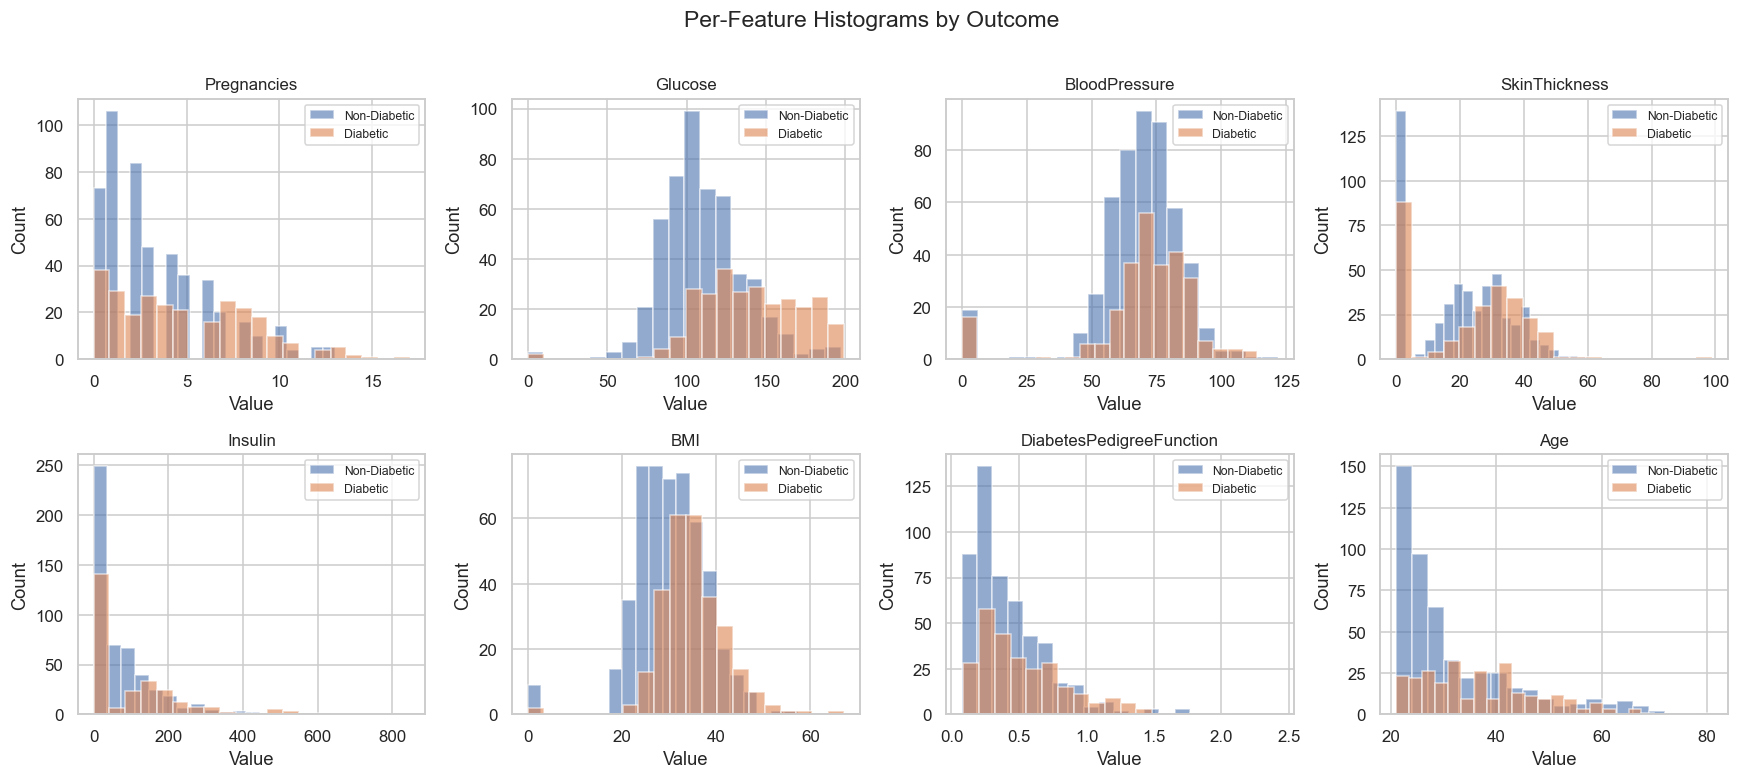

In [8]:
features = [c for c in df.columns if c != 'Outcome']
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, label, color in [(0, 'Non-Diabetic', '#4C72B0'), (1, 'Diabetic', '#DD8452')]:
        axes[i].hist(
            df[df['Outcome'] == outcome][feat],
            bins=20, alpha=0.6, label=label, color=color, edgecolor='white'
        )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

# Hide any spare axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Per-Feature Histograms by Outcome', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 — Boxplots by Outcome

Boxplots highlight median, spread, and outliers for each feature across the two outcome classes. Features with clearly separated boxes (e.g., **Glucose**, **BMI**, **Age**) are strong discriminators between diabetic and non-diabetic patients.

/var/folders/9w/dd74n6cj6zj_jxvbpsw_lb440000gn/T/ipykernel_35763/431399683.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
/var/folders/9w/dd74n6cj6zj_jxvbpsw_lb440000gn/T/ipykernel_35763/431399683.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
/var/folders/9w/dd74n6cj6zj_jxvbpsw_lb440000gn/T/ipykernel_35763/431399683.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
/var/folders/9w/dd74n6cj6zj_jxvbpsw_lb440000gn/T/ipykernel_35763/431399683.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

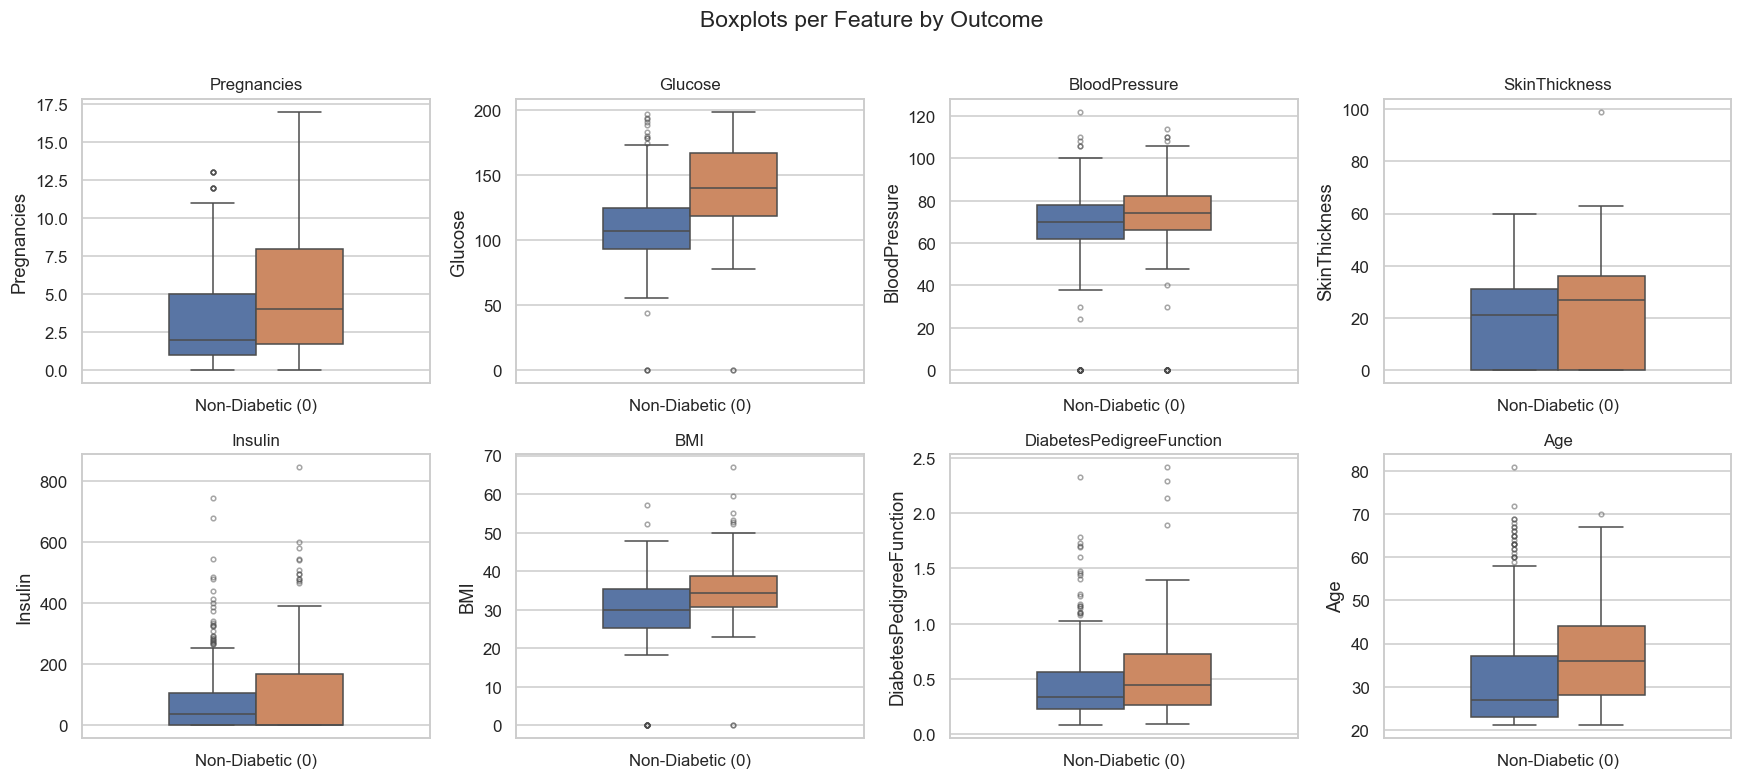

In [10]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(
        data=df, hue='Outcome', legend=False, y=feat,
        palette={0: '#4C72B0', 1: '#DD8452'},
        ax=axes[i], width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.5)
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots per Feature by Outcome', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 2.4 — Medical Context: Why Key Features Matter

| Feature | Medical Relevance |
|---------|------------------|
| **Glucose** | Plasma glucose concentration is the primary biomarker for diabetes diagnosis. Elevated fasting glucose (≥ 126 mg/dL) directly meets the WHO diagnostic threshold for Type 2 diabetes. |
| **BMI** | Body Mass Index is a proxy for excess adipose tissue. Obesity (BMI ≥ 30) drives insulin resistance by promoting chronic low-grade inflammation and reducing insulin receptor sensitivity. |
| **Age** | Insulin-secreting β-cell function naturally declines with age, and cumulative exposure to metabolic stressors increases diabetes risk substantially after age 45. |
| **DiabetesPedigreeFunction** | Encodes family history as a quantitative score, capturing the strong genetic heritability component of Type 2 diabetes (estimated at 40–80%). |
| **Insulin / BloodPressure** | Chronically elevated fasting insulin reflects β-cell compensatory hyper-secretion, while hypertension is both a comorbidity and a risk amplifier for metabolic syndrome. |

---
## Section 3 — Data Preprocessing & Train/Test Split

In [11]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Fit scaler ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only — no fit

print(f'Training set : {X_train_scaled.shape[0]} samples')
print(f'Test set     : {X_test_scaled.shape[0]} samples')
print(f'Features     : {X_train_scaled.shape[1]}')

Training set : 614 samples
Test set     : 154 samples
Features     : 8


---
## Section 4 — Model Implementation

Both classifiers are trained on the **scaled training set** and evaluated on the **scaled test set**.

- **Logistic Regression** — a linear probabilistic classifier that models log-odds as a linear combination of features.
- **Linear Discriminant Analysis (LDA)** — finds a linear combination of features that maximises class separability by modelling class-conditional Gaussian distributions.

In [12]:
# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

# --- Linear Discriminant Analysis ---
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

# Hard predictions
y_pred_lr  = log_reg.predict(X_test_scaled)
y_pred_lda = lda.predict(X_test_scaled)

# Probability scores for ROC
y_prob_lr  = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_lda = lda.predict_proba(X_test_scaled)[:, 1]

print('Both models trained successfully.')

Both models trained successfully.


### 4.1 — Confusion Matrices

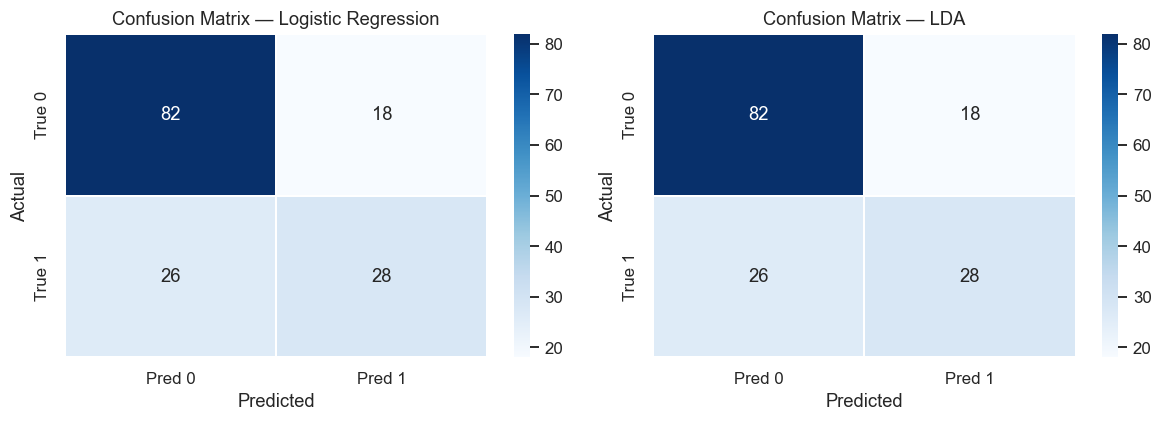

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, cm_data, title in [
    (axes[0], confusion_matrix(y_test, y_pred_lr),  'Logistic Regression'),
    (axes[1], confusion_matrix(y_test, y_pred_lda), 'LDA')
]:
    sns.heatmap(
        cm_data, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1'],
        linewidths=1, ax=ax
    )
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### 4.2 — Classification Metrics

In [14]:
def metrics_report(y_true, y_pred, model_name):
    return {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    metrics_report(y_test, y_pred_lr,  'Logistic Regression'),
    metrics_report(y_test, y_pred_lda, 'LDA'),
]).set_index('Model')

display(results)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,71.43,0.6087,0.5185,0.56
LDA,71.43,0.6087,0.5185,0.56


### 4.3 — ROC Curves

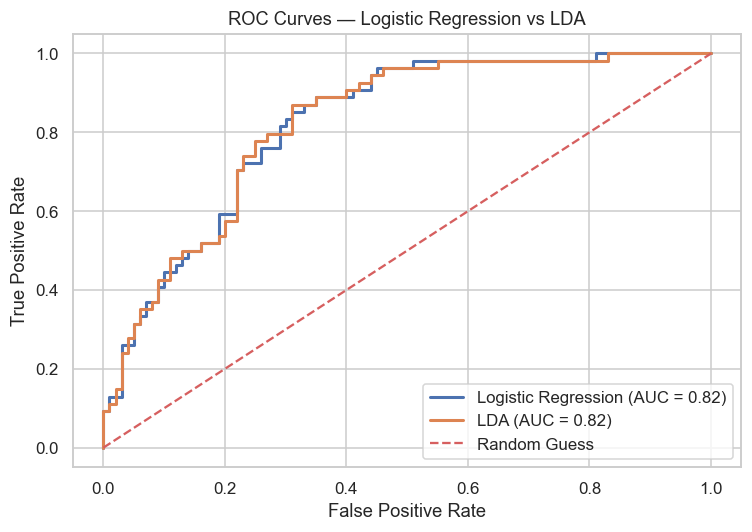

AUC — Logistic Regression : 0.8230
AUC — LDA                 : 0.8237


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

for y_prob, label, color in [
    (y_prob_lr,  'Logistic Regression', '#4C72B0'),
    (y_prob_lda, 'LDA',                 '#DD8452'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'r--', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Logistic Regression vs LDA')
ax.legend()
plt.tight_layout()
plt.show()

print(f'AUC — Logistic Regression : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'AUC — LDA                 : {roc_auc_score(y_test, y_prob_lda):.4f}')

---
## Section 5 — Feature Importance

Coefficients extracted via `model.coef_` indicate the direction and magnitude of each feature's contribution to the classification decision (on the log-odds scale for Logistic Regression).

In [16]:
feature_names = X.columns.tolist()

# ----- Logistic Regression coefficients -----
lr_coef = log_reg.coef_[0]          # shape (n_features,)
lr_feat_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lr_coef
}).sort_values('Coefficient', ascending=False)

print('=== Logistic Regression — Coefficients (model.coef_) ===')
print(lr_feat_df.to_string(index=False))
print(f'\nMost  significant predictor: {lr_feat_df.iloc[0]["Feature"]}')
print(f'Least significant predictor: {lr_feat_df.iloc[-1]["Feature"]}')

print('\n' + '─'*55)

# ----- LDA coefficients -----
lda_coef = lda.coef_[0]
lda_feat_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lda_coef
}).sort_values('Coefficient', ascending=False)

print('\n=== LDA — Coefficients (model.coef_) ===')
print(lda_feat_df.to_string(index=False))
print(f'\nMost  significant predictor: {lda_feat_df.iloc[0]["Feature"]}')
print(f'Least significant predictor: {lda_feat_df.iloc[-1]["Feature"]}')

=== Logistic Regression — Coefficients (model.coef_) ===
                 Feature  Coefficient
                 Glucose     1.144151
                     BMI     0.713893
             Pregnancies     0.373178
DiabetesPedigreeFunction     0.255527
                     Age     0.184179
           SkinThickness     0.066535
                 Insulin    -0.127308
           BloodPressure    -0.197637

Most  significant predictor: Glucose
Least significant predictor: BloodPressure

───────────────────────────────────────────────────────

=== LDA — Coefficients (model.coef_) ===
                 Feature  Coefficient
                 Glucose     1.249547
                     BMI     0.673707
             Pregnancies     0.395207
DiabetesPedigreeFunction     0.276984
                     Age     0.188784
           SkinThickness     0.078300
                 Insulin    -0.132135
           BloodPressure    -0.203838

Most  significant predictor: Glucose
Least significant predictor: BloodPressur

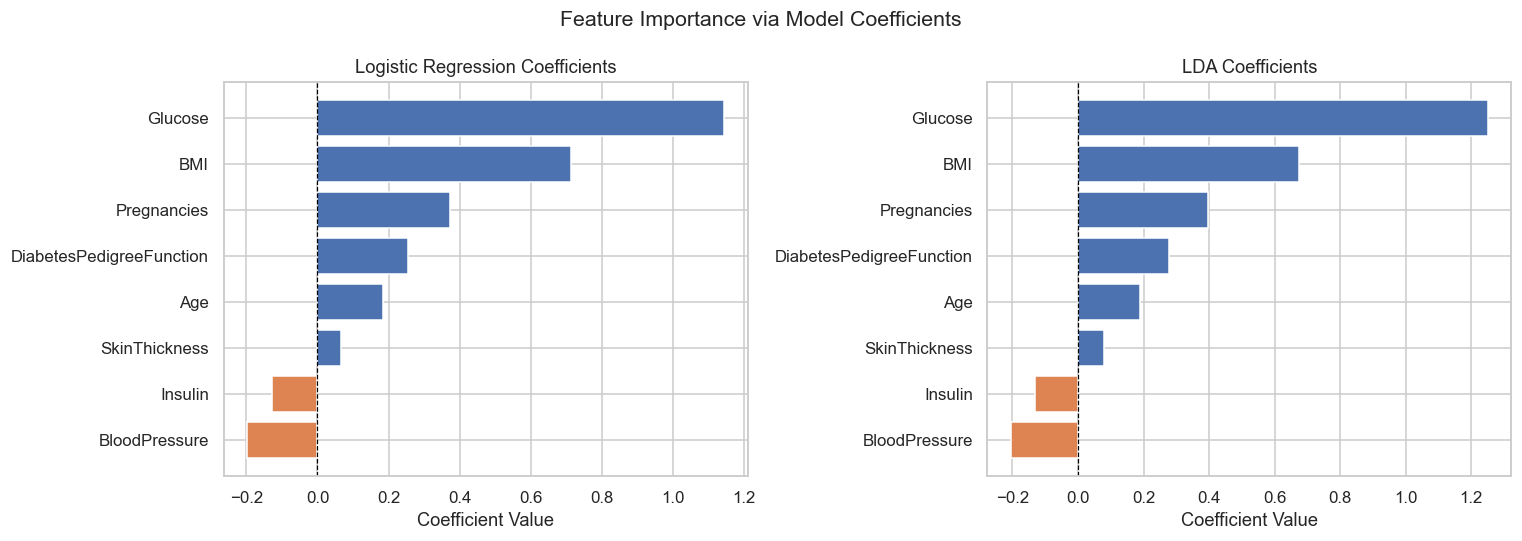

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat_df, title, palette in [
    (axes[0], lr_feat_df,  'Logistic Regression Coefficients',  'RdBu'),
    (axes[1], lda_feat_df, 'LDA Coefficients',                  'RdBu'),
]:
    colors = ['#4C72B0' if v >= 0 else '#DD8452' for v in feat_df['Coefficient']]
    ax.barh(feat_df['Feature'], feat_df['Coefficient'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Coefficient Value')
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()

plt.suptitle('Feature Importance via Model Coefficients', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation

Both models consistently rank **Glucose** as the most influential predictor, aligning with its central role in diabetes diagnosis. **BMI** and **DiabetesPedigreeFunction** are strong secondary predictors, reflecting the physiological pathways described in Section 2.4 (insulin resistance and genetic heritability). **Age** ranks in the mid-tier, consistent with the progressive nature of β-cell decline over time.

---
## Section 6 — Model Comparison Summary

In [18]:
summary = results.copy()
summary['AUC'] = [
    round(roc_auc_score(y_test, y_prob_lr),  4),
    round(roc_auc_score(y_test, y_prob_lda), 4),
]
display(summary)

print('\nConclusion:')
print('Both models perform similarly. Logistic Regression offers better interpretability')
print('via explicit probability calibration, while LDA makes stronger Gaussian assumptions')
print('but can outperform LR when those assumptions hold.')

,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
Logistic Regression,71.43,0.6087,0.5185,0.56,0.8230
LDA,71.43,0.6087,0.5185,0.56,0.8237



Conclusion:
Both models perform similarly. Logistic Regression offers better interpretability
via explicit probability calibration, while LDA makes stronger Gaussian assumptions
but can outperform LR when those assumptions hold.
